# BBC News Classification Kaggle Mini-Project

In this assignment, we will use matrix factorization to predict the category of a news article.

## Importing Data and Brief EDA

Show a few visualizations like histograms. Describe any data cleaning procedures. Based on your EDA, what is your plan of analysis? 

Please feel free to look at online resources on processing raw texts to feature vectors. Many methods process texts to matrix form (word embedding), including TF-IDF, GloVe, Word2Vec, etc. Pick a method and process the raw texts to word embedding. Briefly explain the method(s) and how they work in your own words. Also, do exploratory data analysis such as word statistics and/or visualization.

As we did not learn natural language processing (NLP) specific techniques such as word embeddings in the lectures, we recommend reading discussions and example codes from others in the Kaggle and/or doing some research online to make sure you understand. You can refer to any resource as needed, but make sure you “demonstrate” your understanding- please include explaining in your own words, discussions, and your interpretation. Also importantly, please have a reference list at the end of the report. 

## Reference List

https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html

https://scikit-learn.org/stable/auto_examples/text/plot_document_classification_20newsgroups.html

https://codesignal.com/learn/courses/introduction-to-tf-idf-vectorization-in-python/lessons/customizing-tf-idf-vectorization-parameters-in-nlp

https://stackoverflow.com/questions/55292533/interpret-tf-idf-scores-from-sklearn-tfidfvectorizer

https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.NMF.html#sklearn.decomposition.NMF

https://scikit-learn.org/stable/modules/decomposition.html

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# For Nonnegative Matrix Factorization
import sklearn
from time import time
from sklearn.feature_extraction.text import TfidfVectorizer

# For supervised learning comparison
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.model_selection import GridSearchCV, KFold

from scipy.sparse import coo_matrix, csr_matrix


In [3]:
bbc_test = pd.read_csv('data/bbcnewstest.csv')
bbc_train = pd.read_csv('data/bbcnewstrain.csv')

In [4]:
bbc_train

,ArticleId,Text,Category
0,1833,worldcom ex-boss launches defence lawyers defe...,business
1,154,german business confidence slides german busin...,business
2,1101,bbc poll indicates economic gloom citizens in ...,business
3,1976,lifestyle governs mobile choice faster bett...,tech
4,917,enron bosses in $168m payout eighteen former e...,business
...,...,...,...
1485,857,double eviction from big brother model caprice...,entertainment
1486,325,dj double act revamp chart show dj duo jk and ...,entertainment
1487,1590,weak dollar hits reuters revenues at media gro...,business
1488,1587,apple ipod family expands market apple has exp...,tech


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1490 entries, 0 to 1489
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ArticleId  1490 non-null   int64 
 1   Text       1490 non-null   object
 2   Category   1490 non-null   object
dtypes: int64(1), object(2)
memory usage: 35.1+ KB
None


<Axes: xlabel='Category'>

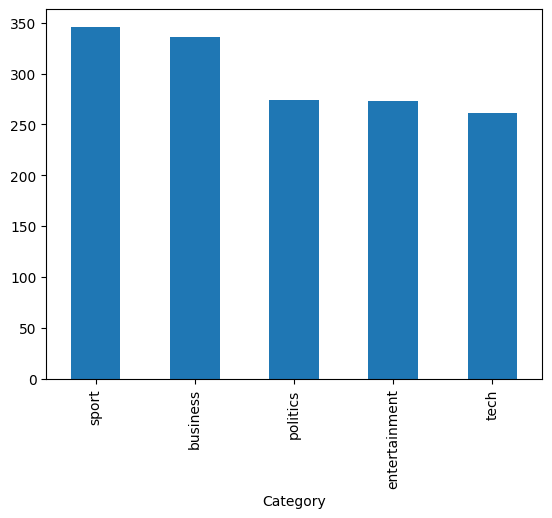

In [5]:
print(bbc_train.info())
bbc_train['Category'].value_counts().plot(kind = "bar")


In [37]:
X_train = bbc_train['Text']
y_train = bbc_train['Category']


## Data Cleaning
This code is originally copied from https://sandipanweb.wordpress.com/2023/12/06/non-negative-matrix-factorization-to-solve-text-classification-and-recommendation-problems/


In [11]:
#for visualization
import seaborn as sns
# from wordcloud import WordCloud, STOPWORDS
 
#for text cleaning / preprocessing
import string, re
import nltk
nltk.download('punkt')
nltk.download('stopwords')
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
 
#for data analysis and modeling
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn import decomposition

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\eltur\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\eltur\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


In [8]:
max_len_train = max(X_train.apply(lambda x: len(x.split())).values)
max_len_train

np.int64(3345)

5


C:\Users\eltur\AppData\Local\Temp\ipykernel_19660\2876511136.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),


,Category,count
0,sport,346
1,business,336
2,politics,274
3,entertainment,273
4,tech,261


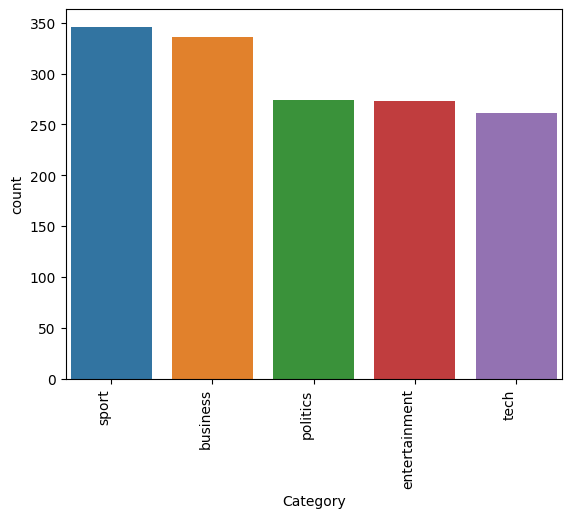

In [12]:
freq_df = pd.DataFrame(y_train.value_counts()).reset_index()
freq_df.columns = ['Category', 'count']
ncats = len(freq_df)
print(ncats)
ax = sns.barplot(data=freq_df, x='Category', y='count', hue='Category')
ax.set_xticklabels(ax.get_xticklabels(), 
                          rotation=90, 
                          horizontalalignment='right')
plt.margins(x=0.01)
freq_df.head()

In [17]:
def clean_text(txt):
     
    #remove punctuations
    txt  = "".join([char if char not in string.punctuation else ' ' for char in txt ])
     
    #process numbers / money
 #   txt = txt.replace('£', '$')
 #   txt = re.sub("\d+", " NUM ", txt) # change numbers to word " NUM "
 #   txt = re.sub('\s+', ' ', txt)   
 #   txt = txt.replace("NUM NUM", "NUM")
 #   txt = txt.replace("$ NUM", "dollar")
 #   txt = txt.replace("NUM bn", "dollar")
 #   txt = txt.replace("dollar bn", "dollar")
 #   txt = txt.replace("dollar dollar", "dollar")
 #   txt = txt.replace("NUM", "")
 #   txt = txt.replace("said", "") # the word said is too frequent, we can see it with word cloud
     
    txt = txt.lower() # lowercase
     
    # split into words
    words = word_tokenize(txt)
     
    # remove stopwords
    stop_words = set(stopwords.words('english'))
    words = [w for w in words if not w in stop_words]
     
    # removing leftover punctuations
    words = [word for word in words if word.isalpha()]
     
    cleaned_text = ' '.join(words)
    return cleaned_text

I'm building my own function to test my own algorithm.

In [114]:
re.search(r"\d+", "In the 1990s it cost $13.4bn.")
re.search(r"\$(\d+).(\d+)bn", "In the 1990s it cost $13.4bn.")
re.search(r"\d+[^\d\W_]", "In the 1990s it cost $13.4bn.")
# Split is not the rigth command here
#re.split(r"\d+[^\d\W_]", "In the 1990s it cost $13.4bn.")
re.search(r"\d\d\d\d", "I paid 123 in 1990 it cost $13.4bn.")
re.search(r"(\d+)\-(\d+)", "I paid 123 in 1990 it cost $13.4bn, I lost 5-12.")


<re.Match object; span=(43, 47), match='5-12'>

This is the code to clean the numbers and money, mostly.  There is a 

In [149]:
def clean_up (txt):
    # $ is removed by the string.punctuation, but pound is not, so this keeps a currency marker
    txt = txt.replace('$','£')
    
    # special number cases, non-financial
    txt = re.sub(r"(\d+).(\d+)\%", "percentnum", txt)
    txt = re.sub(r"(\d+)\%", "percentnum", txt)
    txt = re.sub(r"\d\d\d\d", "YEAR", txt)
    txt = re.sub(r"(\d+)\-(\d+)", "matchscore", txt)
    
    # remove all punctuation, in particular decimals in numbers
    txt = "".join([char if char not in string.punctuation else '' for char in txt])
    
    # turn currency values into text, other numbers into "NUM"
    txt = re.sub(r"\£(\d+)bn", "billioncurrency", txt)
    txt = re.sub(r"\£(\d+)m", "millioncurrency", txt)
    txt = re.sub(r"\d+", "NUM", txt)
    txt = txt.replace(" NUMm euros ", " millioncurrency ")
    txt = txt.replace(" NUMbn euros ", " billioncurrency ")
    txt = txt.replace(" NUM NUM ", " NUM ")
    txt = txt.replace(" NUM NUM ", " NUM ")
    txt = txt.replace(" billioncurrency billioncurrency ", " billioncurrency ")
    txt = txt.replace(" millioncurrency millioncurrency ", " millioncurrency ")
    txt = txt.replace(" millioncurrency billioncurrency ", " billioncurrency ")
    txt = txt.replace(" billioncurrency millioncurrency ", " billioncurrency ")
    
    # txt = txt.lower() # lowercase 
    # words = word_tokenize(txt)
    # removing leftover punctuations
    #words = [word for word in words if word.isalpha()]
     
    #
    #return cleaned_text
    return txt
## If we get here, the two cases I couldn't do 1990s and 2002asserted
    

For counting word frequency I need to tokenize and remove stopwords.

In [ ]:


# split into words
from nltk.tokenize import wordpunct_tokenize
text_ = clean_up(X_train[0])
words = wordpunct_tokenize(text_)

 # remove stopwords
stop_words = set(stopwords.words('english'))
words = [w for w in words if not w in stop_words]

cleaned_text = ' '.join(words)

AttributeError: 'set' object has no attribute 'words'

This is the next set of code that I need to get to work
df_train['Text'] = df_train['Text'].apply(lambda txt: clean_text(txt))

In [151]:
X_train = X_train.apply(lambda txt:clean_up(txt))

X_train[0]

'worldcom exboss launches defence lawyers defending former worldcom chief bernie ebbers against a battery of fraud charges have called a company whistleblower as their first witness  cynthia cooper  worldcom s exhead of internal accounting  alerted directors to irregular accounting practices at the us telecoms giant in YEAR her warnings led to the collapse of the firm following the discovery of an billioncurrency accounting fraud mr ebbers has pleaded not guilty to charges of fraud and conspiracy  prosecution lawyers have argued that mr ebbers orchestrated a series of accounting tricks at worldcom  ordering employees to hide expenses and inflate revenues to meet wall street earnings estimates but ms cooper  who now runs her own consulting business  told a jury in new york on wednesday that external auditors arthur andersen had approved worldcom s accounting in early YEAR and YEAR she said andersen had given a  green light  to the procedures and practices used by worldcom mr ebber s law

Now I need some kind of graphic of word frequency.  

https://www.geeksforgeeks.org/bag-of-word-and-frequency-count-in-text-using-sklearn/

In [152]:
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

# Initializing and Fitting the CountVectorizer
vectorizer = CountVectorizer(stop_words='english')
X = vectorizer.fit_transform(X_train)

# Step 4: Displaying the Vocabulary and Frequency Counts
print("Vocabulary:", vectorizer.vocabulary_)
print("Feature Names:", vectorizer.get_feature_names_out())
print("Bag of Words Representation:\n", X.toarray())

# Step 5: Analyzing Word Frequencies
word_counts = np.sum(X.toarray(), axis=0)
word_freq = dict(zip(vectorizer.get_feature_names_out(), word_counts))
print("Word Frequencies:", word_freq)

Vocabulary: {'worldcom': 24892, 'exboss': 7646, 'launches': 12545, 'defence': 5697, 'lawyers': 12575, 'defending': 5705, 'chief': 3798, 'bernie': 2156, 'ebbers': 6939, 'battery': 1926, 'fraud': 8813, 'charges': 3694, 'called': 3192, 'company': 4386, 'whistleblower': 24631, 'witness': 24794, 'cynthia': 5398, 'cooper': 4866, 'exhead': 7719, 'internal': 11436, 'accounting': 151, 'alerted': 576, 'directors': 6196, 'irregular': 11616, 'practices': 17080, 'telecoms': 22389, 'giant': 9274, 'year': 25048, 'warnings': 24373, 'led': 12646, 'collapse': 4230, 'firm': 8377, 'following': 8602, 'discovery': 6265, 'billioncurrency': 2266, 'mr': 14552, 'pleaded': 16788, 'guilty': 9746, 'conspiracy': 4689, 'prosecution': 17529, 'argued': 1187, 'orchestrated': 15705, 'series': 20076, 'tricks': 23130, 'ordering': 15710, 'employees': 7210, 'hide': 10285, 'expenses': 7778, 'inflate': 11192, 'revenues': 18900, 'meet': 13866, 'wall': 24309, 'street': 21624, 'earnings': 6894, 'estimates': 7517, 'ms': 14556, 'r

The internet says word clouds are the main way to visualize word frequencies.  https://www.geeksforgeeks.org/generating-word-cloud-python/

In [153]:
import re
from wordcloud import STOPWORDS

text = ' '.join(X_train.astype(str).tolist())

#text = re.sub(r'[^A-Za-z\s]', '', text)

#text = text.lower()

stopwords = set(STOPWORDS)
text = ' '.join(word for word in text.split() if word not in stopwords)

After my initial attempt at tokenization, I got the following word cloud, which led me to go back and revisit cleaning the text cleaning .

![title](initialwc.png)

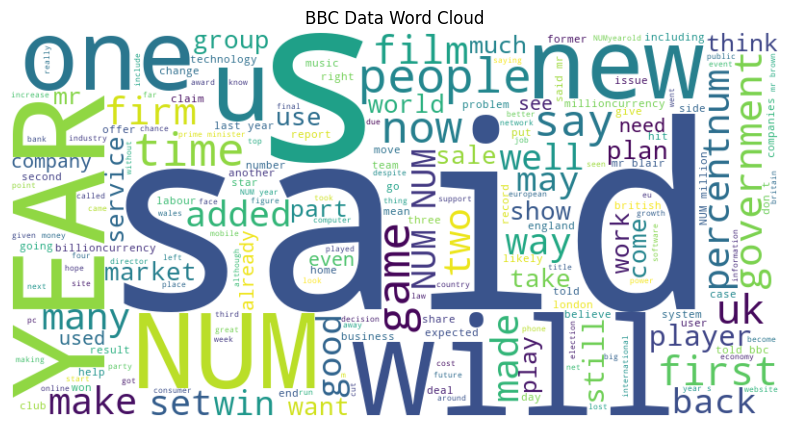

In [154]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  
plt.title("BBC Data Word Cloud")
plt.show()

I'm going to use what I learned from that word cloud to build a better text cleaner.  What did I learn?
1) I still have NUM NUM, which is weird.  What is going on there?  Why aren't they split?
2) the lone s, th e lone u (what is that from)?
3) aren't "said" and "will" stop words?  Will skikit learn recognize them as stop words?
4) don t
5) 

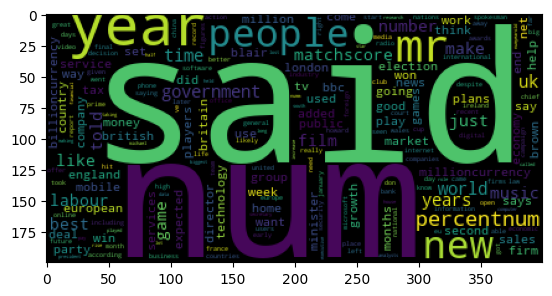

In [158]:
wc = WordCloud().generate_from_frequencies(word_freq)
plt.imshow(wc)

## This is actually in the analysis section.

Now we need to do some data preprocessing to turn the text into "numerical" data.

Below, I am using the TF-IDF method to turn the text data into a matrix which can be analyzed.  In TF-IDF, for each document/text/article (document), each word earns two scores: a term frequency score (TF) and an inverse document frequency score (IDF).  These scores are multiplied together to get the numeric value for the term and document pair in the TF-IDF matrix.  TF is obtained by a count of times the term occurs in the document, divided by the total number of terms in the document. The IDF is the *log* of the quantity obtained by dividing the total number of documents in the dataset by *1 plus* the number of documents in the dataset containing the word.  

In [155]:

vectorizer = TfidfVectorizer(stop_words='english')
X_numeric = vectorizer.fit_transform(X_train)
print(X_numeric)
feature_names = vectorizer.get_feature_names_out()
print(feature_names)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 207511 stored elements and shape (1490, 25193)>
  Coords	Values
  (0, 24892)	0.49690348352546765
  (0, 7646)	0.0693102616672951
  (0, 12545)	0.05449895342454461
  (0, 5697)	0.040832395454284943
  (0, 12575)	0.14794958055528595
  (0, 5705)	0.04931652685176199
  (0, 3798)	0.08313816995806189
  (0, 2156)	0.058747155023300766
  (0, 6939)	0.34640471105684256
  (0, 1926)	0.05521149816949641
  (0, 8813)	0.17308993397331782
  (0, 3694)	0.12200409979048855
  (0, 3192)	0.030664093117942846
  (0, 4386)	0.05326430785442359
  (0, 24631)	0.07320879003944508
  (0, 24794)	0.11546823701894751
  (0, 5398)	0.0693102616672951
  (0, 4866)	0.22392442049442543
  (0, 7719)	0.07320879003944508
  (0, 11436)	0.053215055223911956
  (0, 151)	0.35107196068660473
  (0, 576)	0.06439869678131813
  (0, 6196)	0.04783437515270024
  (0, 11616)	0.0665442117676007
  (0, 17080)	0.11196221024721272
  :	:
  (1489, 19846)	0.11749448422699645
  (1489, 13412)	0.1561713

We see that in the resulting vectorization, rows correspond to terms and columns correpond to articles.  From the list of "words" or feature terms, we see that the default setting in the scikit-learn implementation of the TF-IDF algorithm includes numerical values in the set of terms.  There are various ways to deal with this, but because some numerical values can informative, I have decided to treat them just like any other term.

(array([2.0214e+04, 2.0530e+03, 7.9400e+02, 4.0900e+02, 3.0100e+02,
        1.6800e+02, 1.3000e+02, 9.2000e+01, 6.1000e+01, 6.4000e+01,
        3.5000e+01, 3.0000e+01, 2.2000e+01, 1.9000e+01, 1.3000e+01,
        6.0000e+00, 1.2000e+01, 7.0000e+00, 4.0000e+00, 4.0000e+00,
        3.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00, 2.0000e+00,
        3.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        1.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00, 1.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.00

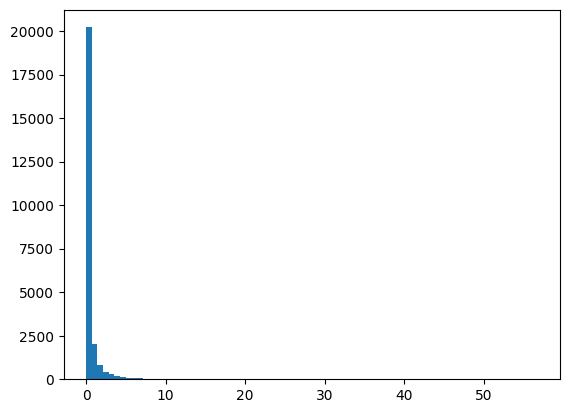

In [48]:
# row sums
X_numeric.toarray().sum(axis = 1)
# plotting a histogram of column sums
plt.hist(X_numeric.toarray().sum(axis = 0), bins = 80)

We see that there are still terms that are 

Among the scikit-learn parameters are max_df and min_df.  In the updated vectorization below, I have set max_df at 0.5.  Because I used a float between 0 and 1, words which occur in 50% of the documents (i.e. with document frequency above 0.5) will be treated like "stop words" for this data set.  They occur too frequently to be useful in differentiating text.  On the other hand, for min_df I used an integer.  This tells scikit-learn that I am looking for a minimum absolute count of 2 for terms between documents.  This will rule out terms that occur in only one document.  Because we are doing non-negative matrix factorization, and terms which show up in only one document cannot occur in latent factors of the dataset, and removing them will speed up the analysis without changing accuracy.

In [46]:
# max_df (document frequency) 
vectorizer_2 = TfidfVectorizer(stop_words='english', max_df=0.5, min_df=2)
X_2 = vectorizer_2.fit_transform(X_train)
print(X_2)
feature_names_2 = vectorizer_2.get_feature_names_out()

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 201413 stored elements and shape (1490, 14064)>
  Coords	Values
  (0, 13915)	0.49864687813280256
  (0, 4758)	0.08369099292507158
  (0, 1919)	0.03673634470050856
  (0, 7368)	0.054690163960706764
  (0, 3676)	0.04081071777313066
  (0, 7385)	0.14846866425956498
  (0, 3684)	0.04948955475318832
  (0, 2584)	0.08304982036840315
  (0, 1676)	0.058953270449454025
  (0, 4382)	0.3476200780752566
  (0, 1552)	0.055405208681422506
  (0, 5412)	0.17369722304952245
  (0, 2526)	0.12243215331939199
  (0, 2244)	0.028793541547241213
  (0, 2913)	0.053451186614898345
  (0, 13864)	0.11403412293299933
  (0, 3511)	0.06955343793880446
  (0, 3234)	0.22471006326024148
  (0, 6064)	0.03488825220447407
  (0, 6796)	0.05340176118066672
  (0, 647)	0.3523037028323934
  (0, 905)	0.06462464074108148
  (0, 3974)	0.04800220289883472
  (0, 6896)	0.0667776833044108
  (0, 9639)	0.11235503163012074
  :	:
  (1489, 7809)	0.04891884244637783
  (1489, 1053)	0.06627541690296

(array([8.441e+03, 2.359e+03, 1.099e+03, 5.560e+02, 3.750e+02, 2.580e+02,
        2.250e+02, 1.480e+02, 8.700e+01, 9.400e+01, 6.600e+01, 6.200e+01,
        4.400e+01, 4.600e+01, 3.400e+01, 2.600e+01, 2.100e+01, 2.000e+01,
        1.400e+01, 1.600e+01, 1.000e+01, 9.000e+00, 7.000e+00, 6.000e+00,
        5.000e+00, 5.000e+00, 6.000e+00, 3.000e+00, 3.000e+00, 3.000e+00,
        4.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 1.000e+00, 0.000e+00,
        2.000e+00, 1.000e+00, 2.000e+00, 1.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00]),
 array

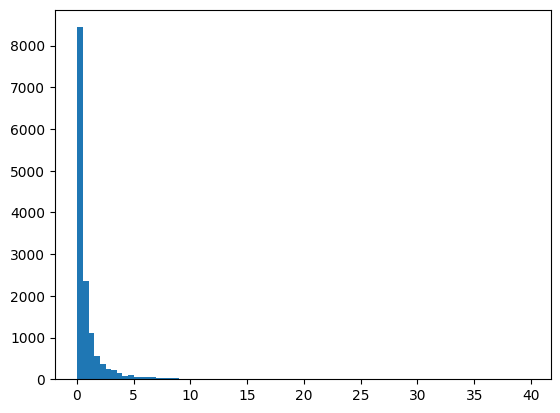

In [49]:
# plotting a histogram of column sums
plt.hist(X_2.toarray().sum(axis = 0), bins = 80)

## Model Building and Training (Unsupervised)

In the Kaggle competition, the training data has labels (category). Thus, it can be solved using supervised learning. In general, the more labeled data we have, the more accurate the supervised learning model will be. But unsupervised learning can be powerful even when there is a small number of labels or no labels. This assignment will apply an unsupervised approach, especially the matrix factorization method, to discover topics in the news articles and use the labels to check the accuracy.

Here are some steps to guide this section: 
1) Think about this and answer: when you train the unsupervised model for matrix factorization, should you include texts (word features) from the test dataset or not as the input matrix? Why or why not?
2) Build a model using the matrix factorization method(s) and predict the train and test data labels. Choose any hyperparameter (e.g., number of word features) to begin with.
3) Measure the performances on predictions from both train and test datasets. You can use accuracy, confusion matrix, etc., to inspect the performance. You can get accuracy for the test data by submitting the result to Kaggle. 
4) Change hyperparameter(s) and record the results. We recommend including a summary table and/or graphs.
5) Improve the model performance if you can- some ideas may include but are not limited to; using different feature extraction methods, fit models in different subsets of data, ensemble the model prediction results, etc. 

In [ ]:
# Use sklearn matric factorization

## Supervised methods for comparison

Use the following steps to guide your work:

1) Pick and train a supervised learning method(s) and compare the results (train and test performance)
2) Discuss comparison with the unsupervised approach. You may try changing the train data size (e.g., Include only 10%, 20%, 50% of labels, and observe train/test performance changes). Which methods are data-efficient (require a smaller amount of data to achieve similar results)? What about overfitting?

## Results and comparisons

Go onto k- means clustering and 

class sklearn.decomposition.NMF(n_components='auto', *, init=None, solver='cd', beta_loss='frobenius', tol=0.0001, max_iter=200, random_state=None, alpha_W=0.0, alpha_H='same', l1_ratio=0.0, verbose=0, shuffle=False)

In [4]:
from sklearn.decomposition import NMF

In [ ]:
MF = NMF(n_components=5, init=None, solver='cd', beta_loss='frobenius', 
                                tol=0.0001, max_iter=200, random_state=None, alpha_W=0.0, alpha_H='same', 
                                l1_ratio=0.0, verbose=0, shuffle=False)
matrix_factorization = MF.fit_transform(X_vector)
MF.components_.shape

In [ ]:
X_vector.shape

(1490, 24456)

In [ ]:
matrix_factorization.shape

(1490, 5)

In [ ]:
def label_permute_compare(ytdf,yp,n=5):
    """
    ytdf: labels dataframe object
    yp: clustering label prediction output
    Returns permuted label order and accuracy. 
    Example output: (3, 4, 1, 2, 0), 0.74 
    """
    Y = ytdf
    Y['Predicted'] = yp
    list_labels = ('BRCA', 'KIRC', 'COAD', 'LUAD', 'PRAD')
    Z = np.zeros((5,5))
    grouped = Y.groupby(['Class'])
    for l in range(5):
        just_l = grouped.get_group(list_labels[l])
        unique, counts = np.unique(just_l['Predicted'], return_counts=True)
        for i in range(len(unique)):
            Z[l][unique[i]] = counts[i]
    print(Z)
    L = range(5)
    champ = 0
    A = set(L)
    for i in A:
        R = A.difference({i})
        for j in R:
            S = R.difference({j})
            for k in S:
                T = S.difference({k})
                for l in T:
                    U = T.difference({l})
                    m = U.pop()
                    correct_count = Z[0][i] + Z[1][j] + Z[2][k] + Z[3][l] + Z[4][m]
                    if correct_count > champ:
                        champ = correct_count
                        L = (i,j,k,l,m)
    return L, champ/len(yp)
# your code here


In [ ]:
labelorder, acc = label_permute_compare(label, model.labels_)
print(labelorder, acc)

# Part 2 of the Assignment

In [5]:
# Import Movie Data
users = pd.read_csv('data/users.csv')
movies = pd.read_csv('data/movies.csv')
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')
train.head()


,uID,mID,rating
0,744,1210,5
1,3040,1584,4
2,1451,1293,5
3,5455,3176,2
4,2507,3074,5


In [6]:
movies.shape

(3883, 21)

In [ ]:
# Create an indexing system
mid2idx = dict(zip(movies.mID,list(range(len(movies)))))
uid2idx = dict(zip(users.uID,list(range(len(users)))))

ind_movie = [mid2idx[x] for x in train.mID] 
ind_user = [uid2idx[x] for x in train.uID]

# Turn the train data set in to a matrix with rows indexed by user index, column by movie index
rating_train = list(train.rating)
        
ratings_uidx_midx = np.array(coo_matrix((rating_train, (ind_user, ind_movie)), shape=(len(users['uID']), len(movies['mID']))).toarray())

# Change rating matrix to float32
ratings_uidx_midx = ratings_uidx_midx.astype(np.float32)
ratings_sp = coo_matrix((rating_train, (ind_user, ind_movie)), shape=(len(users['uID']), len(movies['mID'])))


In [8]:
# Checking sizes
print(train.shape)
print(users.shape)
print(movies.shape)
print(ratings_uidx_midx.shape)
print(ratings_uidx_midx.dtype)

(700146, 3)
(6040, 5)
(3883, 21)
(6040, 3883)
float32


In [9]:
# Method 1 - replace all unrated by user average
ratings_users = ratings_uidx_midx.copy()
masked = np.ma.masked_equal(ratings_users,0)
row_means = masked.mean(axis = 1).data
for i in range(len(users['uID'])):
    ratings_users[i][np.where(ratings_users[i] == 0)] = row_means[i]
    

In [10]:
# Verify that all users rated at least one movie
print(np.where(ratings_users == 0))
ratings_users

(array([], dtype=int64), array([], dtype=int64))


array([[5.       , 4.214286 , 4.214286 , ..., 4.214286 , 4.214286 ,
        4.214286 ],
       [3.6489363, 3.6489363, 3.6489363, ..., 3.6489363, 3.6489363,
        3.6489363],
       [3.9142857, 3.9142857, 3.9142857, ..., 3.9142857, 3.9142857,
        3.9142857],
       ...,
       [4.       , 4.       , 4.       , ..., 4.       , 4.       ,
        4.       ],
       [3.8255813, 3.8255813, 3.8255813, ..., 3.8255813, 3.8255813,
        3.8255813],
       [3.       , 3.495614 , 3.495614 , ..., 3.495614 , 3.495614 ,
        3.495614 ]], dtype=float32)

In [11]:
# Method 2 - replace all unrated by movie
ratings_movies = ratings_uidx_midx.copy().T
masked = np.ma.masked_equal(ratings_movies,0)
col_means = masked.mean(axis = 1).data
for i in range(len(movies['mID'])):
    ratings_movies[i][np.where(ratings_movies[i] == 0)] = col_means[i]
ratings_movies = ratings_movies.T

# Verify that each movie has been rated at least once
ratings_movies[ratings_movies ==0]

array([0., 0., 0., ..., 0., 0., 0.], dtype=float32)

Giving up on Method 2 for now because some movies have not been rated.

In [12]:
# Method 3 - Center Matrix
ratings_centered = ratings_uidx_midx.copy()
masked = np.ma.masked_equal(ratings_centered,0)
row_means = masked.mean(axis = 1).data
for i in range(len(users['uID'])):
    ratings_centered[i][np.where(ratings_centered[i] != 0)] = \
    ratings_centered[i][np.where(ratings_centered[i] != 0)] - row_means[i]

Can't pass negative values to NMF so this is out as well.

In [13]:
# Building the matrix factorization for ratings_users
MF_users = NMF(n_components=75, init=None, solver='cd', beta_loss='frobenius', 
                                tol=0.0001, max_iter=300, random_state=None, alpha_W=0.0, alpha_H='same', 
                                l1_ratio=0.0, verbose=0, shuffle=False)
matrix_factorization = MF_users.fit_transform(ratings_users)
matrix_components = MF_users.components_

In [14]:
# Verifying that we got what we expected
print(matrix_factorization.shape)
print(matrix_components.shape)

(6040, 75)
(75, 3883)


In [15]:
# Build the prediction matrix.  Examine one row
predicted = np.dot(matrix_factorization, matrix_components)
to_experiment = predicted[1]

In [16]:
print(to_experiment.mean())
print(to_experiment.max())
print(to_experiment.min())
print(to_experiment.std())

3.6481655
4.6192937
3.2757313
0.049744792


In [17]:
print(ratings_uidx_midx[1][ratings_uidx_midx[1]!=0].mean())
print(ratings_uidx_midx[1].max())
print(ratings_uidx_midx[1][ratings_uidx_midx[1]!=0].min())
print(ratings_uidx_midx[1][ratings_uidx_midx[1]!=0].std())

3.6489363
5.0
1.0
0.9968829


In [18]:
# Finding n_components with highest std dev.
nc = [75, 80]
mean1 = []
max1 = []
min1 = []
std1 = []
for i in nc:
    MF_users = NMF(n_components=i, init=None, solver='cd', beta_loss='frobenius', 
                                tol=0.0001, max_iter=300, random_state=None, alpha_W=0.0, alpha_H='same', 
                                l1_ratio=0.0, verbose=0, shuffle=False)
    matrix_factorization = MF_users.fit_transform(ratings_users)
    matrix_components = MF_users.components_
    predicted = np.dot(matrix_factorization, matrix_components)
    to_experiment = predicted[1]
    mean1.append(to_experiment.mean())
    max1.append(to_experiment.max())
    min1.append(to_experiment.min())
    std1.append(to_experiment.std())

In [19]:
results = pd.DataFrame([mean1, max1, min1, std1])
print(results)

          0         1
0  3.648849  3.641003
1  4.991008  4.065038
2  2.981481  3.282478
3  0.057363  0.187097


In [20]:
test.head()

,uID,mID,rating
0,2233,440,4
1,4274,587,5
2,2498,454,3
3,2868,2336,5
4,1636,2686,5


In [25]:
y_pred = [0] * len(test.uID)
for i in range(len(test.uID)):
    y_pred[i] = predicted[(uid2idx[test.uID[i]], mid2idx[test.mID[i]])]

print(np.array(y_pred))       
yt=np.array(test.rating)

rmse = np.sqrt(((yt-y_pred)**2).mean())
rmse


[3.3314064 2.8382604 3.1371338 ... 3.8474028 3.2302315 2.680972 ]


np.float64(1.0327321897607464)